In [ ]:
# import os
# import numpy as np
# import rasterio

# # 输入和输出路径
# input_folder = r"H:\7.Eco_parameter\Hunan_LULC\LULC_result\annual_LC_from_1"
# output_path = r"H:\7.Eco_parameter\Hunan_LULC\LULC_result\Change_frequency.tif"

# # 读取所有LC年份文件
# lc_files = sorted([os.path.join(input_folder, f) for f in os.listdir(input_folder) if f.endswith('.tif')])

# # 假设所有tif的地理参数相同
# with rasterio.open(lc_files[0]) as src:
#     meta = src.meta.copy()
#     rows, cols = src.shape

# # 读取所有栅格到三维数组 (year, row, col)
# lc_stack = np.array([rasterio.open(f).read(1) for f in lc_files])

# # 计算像元34年间值的变化频率
# # 这里定义为该像元类别变化次数
# freq = np.sum(lc_stack[1:] != lc_stack[:-1], axis=0).astype(np.int16)  # 统计变化次数

# # 保存结果
# meta.update(dtype='int16', count=1)
# with rasterio.open(output_path, 'w', **meta) as dst:
#     dst.write(freq, 1)

# print("频率结果已保存到：", output_path)

频率结果已保存到： H:\7.Eco_parameter\Hunan_LULC\LULC_result\Change_frequency.tif


C:\Users\DELL\AppData\Local\Temp\ipykernel_138028\1823625337.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


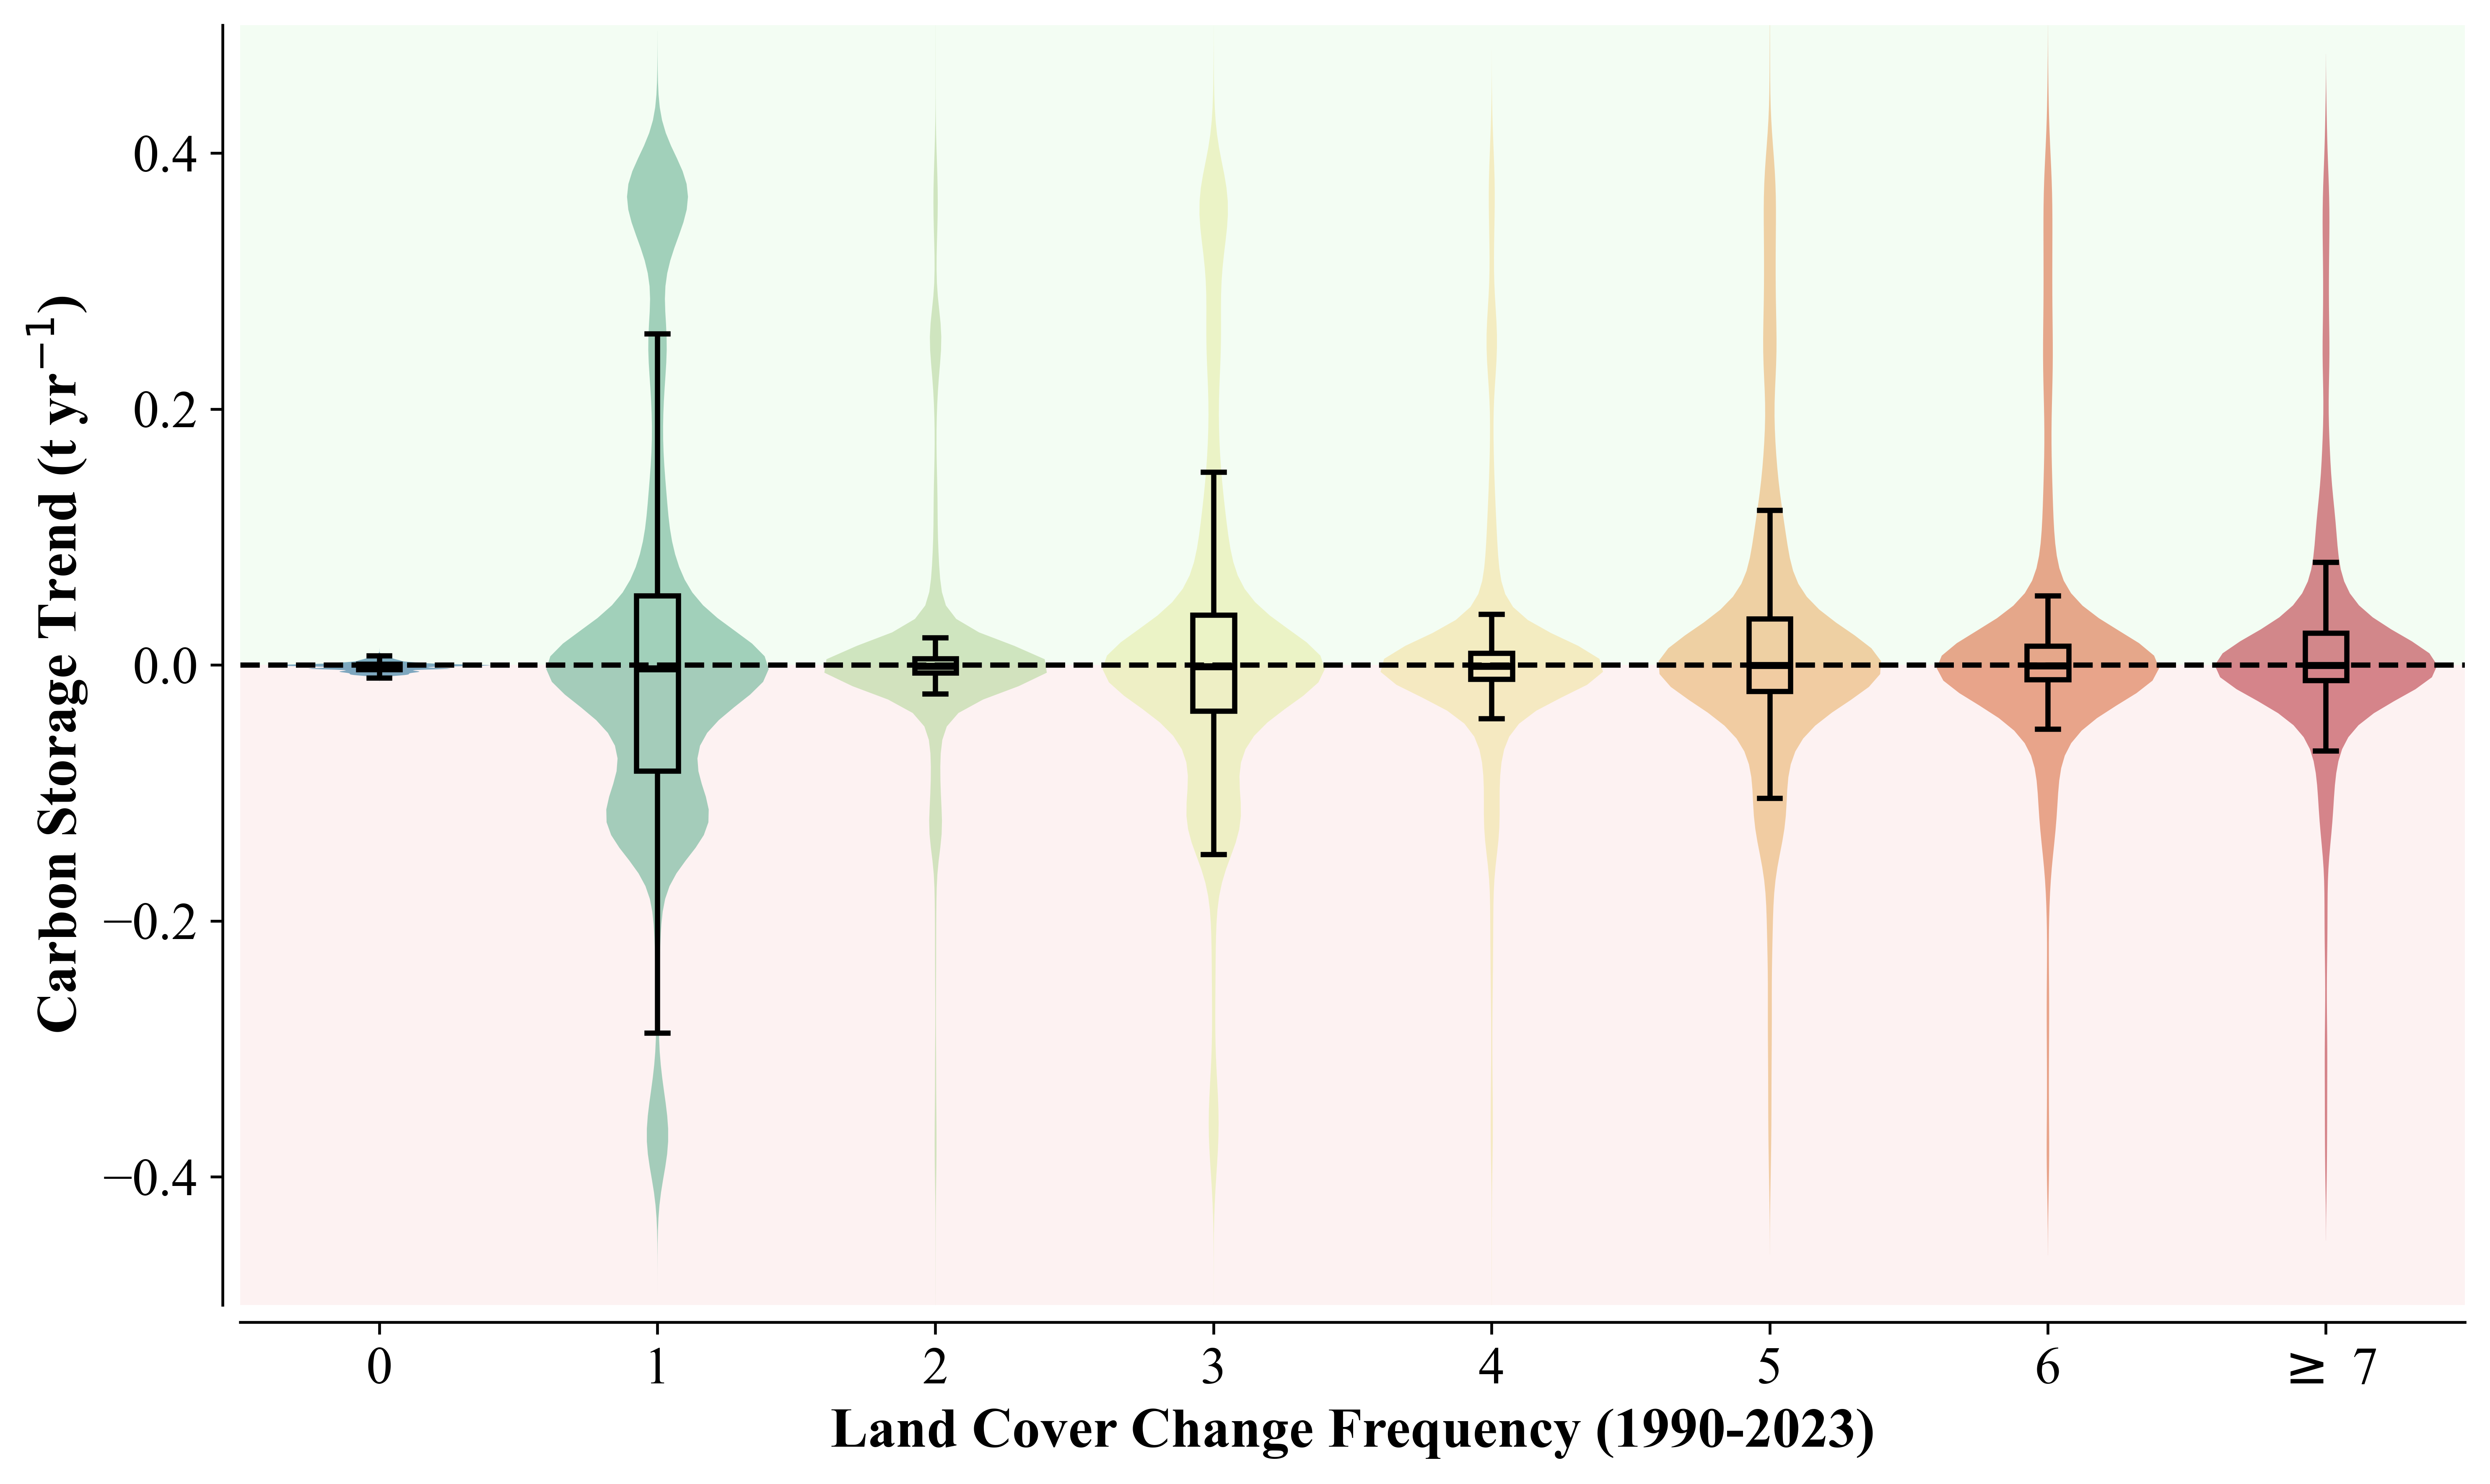

In [ ]:
import numpy as np
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 路径设置 (请确保路径与你的本地路径一致)
ts_slope_path = r"H:\7.Eco_parameter\Hunan_LULC\Revised_Carbon\Trend_Analysis\TS_slope.tif"
change_freq_path = r"H:\7.Eco_parameter\Hunan_LULC\LULC_result\Change_frequency_compressed.tif"

# 2. 读取数据与掩膜处理
with rasterio.open(ts_slope_path) as src1:
    ts_slope = src1.read(1)
with rasterio.open(change_freq_path) as src2:
    change_freq = src2.read(1)

# 保持两个图层shape一致，并掩蔽无效值（排除 NoData 值，如 -9999）
mask = (~np.isnan(ts_slope)) & (~np.isnan(change_freq)) & (ts_slope != -9999) & (change_freq != -9999)
masked_slope = ts_slope[mask]
masked_freq = change_freq[mask]

# 3. 扩大采样量与构建数据框
# 为了让小提琴图的核密度估计更平滑、更具统计代表性，这里随机抽取 100,000 个点
np.random.seed(42)
num_points = min(100000, masked_slope.size) 
indices = np.random.choice(masked_slope.size, num_points, replace=False)

df = pd.DataFrame({
    'Change_Frequency': masked_freq[indices],
    'TS_Slope': masked_slope[indices]
})

# 4. 数据清洗：处理长尾数据
# 将频次 >= 7 的数据归为一类 "≥ 7"，避免尾部极少数数据拉扯图形
df['Freq_Group'] = df['Change_Frequency'].apply(lambda x: '$\geq$ 7' if x >= 7 else str(int(x)))
order = ['0', '1', '2', '3', '4', '5', '6', '$\geq$ 7']

# 5. 顶级科研绘图设置
plt.rcParams['font.family'] = 'Times New Roman' # 使用顶级期刊常用的无衬线字体
fig, ax = plt.subplots(figsize=(10, 6), dpi=600) # 设置高分辨率

# 绘制底层：小提琴图 (展示数据的核密度分布，越宽代表数据越集中)
sns.violinplot(
    data=df, x='Freq_Group', y='TS_Slope', order=order,
    inner=None, linewidth=0, ax=ax, 
    palette='Spectral_r', alpha=0.7 # Spectral_r 色带能很好地体现冷暖过渡
)

# 绘制中层：透明箱线图 (展示中位数、上下四分位数)
sns.boxplot(
    data=df, x='Freq_Group', y='TS_Slope', order=order,
    width=0.15, ax=ax, showfliers=False, # 隐藏离群点，保持图面整洁
    boxprops={'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 1.5, 'zorder': 2},
    whiskerprops={'color': 'black', 'linewidth': 1.5}, 
    capprops={'color': 'black', 'linewidth': 1.5},
    medianprops={'color': 'black', 'linewidth': 2}
)

# 绘制上层：零值基准线 (区分碳汇增加与碳流失)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=3)

# 可选：添加区域背景色进一步区分 Sink (碳汇) 和 Source (碳源)
ax.axhspan(0, df['TS_Slope'].max() + 0.1, facecolor='lightgreen', alpha=0.1, zorder=0)
ax.axhspan(df['TS_Slope'].min() - 0.1, 0, facecolor='lightcoral', alpha=0.1, zorder=0)

# 6. 细节美化与标签
ax.set_xlabel('Land Cover Change Frequency (1990-2023)', fontsize=16, fontweight='bold')
ax.set_ylabel('Carbon Storage Trend (t yr$^{-1}$)', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=15)

# 移除顶部和右侧冗余边框
sns.despine(trim=False, offset=5)

# 根据你的实际数据极值，可以取消下面这行的注释来限制Y轴显示范围，去除极端异常值的视觉干扰
ax.set_ylim(-0.5, 0.5) 

plt.tight_layout()

# 保存高质量图片 (可选)
# plt.savefig(r'H:\7.Eco_parameter\Figures\变化频次与变化率对比\sen_frequency.png', format='png', bbox_inches='tight')

plt.show()